1. Loading and cleaning metadata TSV...
2. Extracting frequencies from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5...
3. Merging with metadata...

4. Training Classifier
Total valid samples: 3224
Number of unique strains: 83

Training Random Forest...

>>> Model: tailhip | Stage: stage3 <<<
>>> Accuracy on Test Set: 35.81% <<<

Classification Report (Top 5 Strains):
                   precision    recall  f1-score   support

B6CAST-129SPWK-F2       0.18      0.78      0.30        36
           FVB/NJ       0.48      0.93      0.63        14
           DBA/2J       0.30      0.23      0.26        13
            BXD34       0.40      0.80      0.53        10
        C57BL/6NJ       0.00      0.00      0.00         9

        micro avg       0.25      0.63      0.35        82
        macro avg       0.27      0.55      0.35        82
     weighted avg       0.26      0.63      0.35   

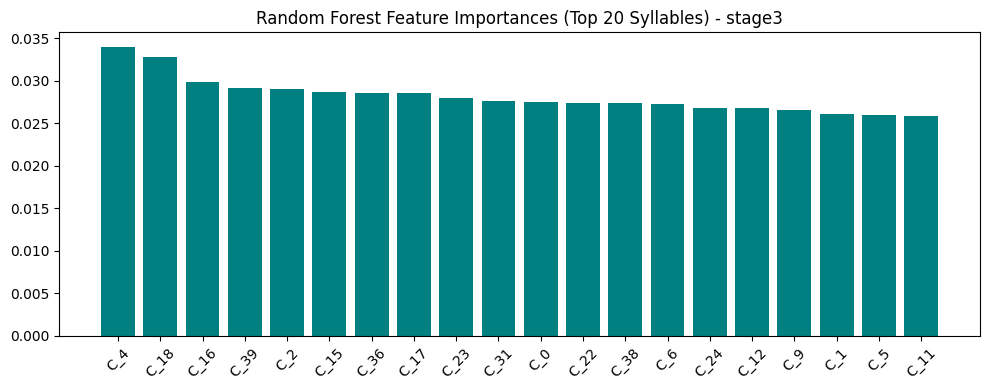

In [1]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Configuration ---
# Pointing to the newly generated file
GMM_H5_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5"
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

STAGE = "stage3"  
K_CLUSTERS = 40

print("1. Loading and cleaning metadata TSV...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

print(f"2. Extracting frequencies from {GMM_H5_PATH}...")
features_list = []

with h5py.File(GMM_H5_PATH, 'r') as f:
    video_names = list(f.keys())
    
    for vid in video_names:
        parts = vid.split('_')
        if len(parts) < 3:
            continue
            
        animal_id = parts[0]
        exp_stage = parts[1]
        age = parts[2]
        
        dataset_path = f"{vid}/{STAGE}/k_{K_CLUSTERS}"
        if dataset_path not in f:
            continue
            
        labels = f[dataset_path][:]
        
        # Calculate frequencies
        counts = np.bincount(labels, minlength=K_CLUSTERS)
        freqs = counts / len(labels) 
        
        row_data = {
            'video_name': vid,
            'animal_id': animal_id,
            'exp_stage': exp_stage,
            'age': age
        }
        
        for i in range(K_CLUSTERS):
            row_data[f'cluster_{i}'] = freqs[i]
            
        features_list.append(row_data)

freq_df = pd.DataFrame(features_list)

print("3. Merging with metadata...")
master_df = pd.merge(freq_df, meta_df, on='animal_id', how='inner')

# --- Classification Pipeline ---
print("\n" + "="*50)
print("4. Training Classifier")
print("="*50)

# We only want to predict strain, so we'll drop rows where strain is missing
master_df = master_df.dropna(subset=['strain'])

# Our features (X) are the 40 cluster frequency columns
feature_cols = [f'cluster_{i}' for i in range(K_CLUSTERS)]
X = master_df[feature_cols].values

# Our target (y) is the strain
y = master_df['strain'].values

print(f"Total valid samples: {len(X)}")
print(f"Number of unique strains: {len(np.unique(y))}")

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining Random Forest...")
# We use a Random Forest because it handles tabular frequency data beautifully
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n>>> Model: tailhip | Stage: {STAGE} <<<")
print(f">>> Accuracy on Test Set: {acc * 100:.2f}% <<<")
# print(f"(Baseline to beat: 35.00%)")

# Let's see the detailed breakdown for the top 5 most common strains in the test set
top_strains = pd.Series(y_test).value_counts().nlargest(5).index.tolist()
print("\nClassification Report (Top 5 Strains):")
print(classification_report(y_test, y_pred, labels=top_strains, zero_division=0))

# Feature Importance Plot
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
plt.title(f"Random Forest Feature Importances (Top 20 Syllables) - {STAGE}")
plt.bar(range(20), importances[indices][:20], align="center", color='teal')
plt.xticks(range(20), [f"C_{i}" for i in indices[:20]], rotation=45)
plt.tight_layout()
plt.show()

1. Loading and cleaning metadata TSV...
2. Extracting frequencies from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5...
3. Merging with metadata...

4. Training Classifier
Total valid samples: 3224
Number of unique strains: 83

Training Random Forest...

>>> Model: tailhip | Stage: stage2 <<<
>>> Accuracy on Test Set: 36.43% <<<

Classification Report (Top 5 Strains):
                   precision    recall  f1-score   support

B6CAST-129SPWK-F2       0.24      0.69      0.35        36
           FVB/NJ       0.41      0.64      0.50        14
           DBA/2J       0.18      0.31      0.23        13
            BXD34       0.60      0.60      0.60        10
        C57BL/6NJ       0.50      0.22      0.31         9

        micro avg       0.28      0.56      0.37        82
        macro avg       0.39      0.49      0.40        82
     weighted avg       0.33      0.56      0.38   

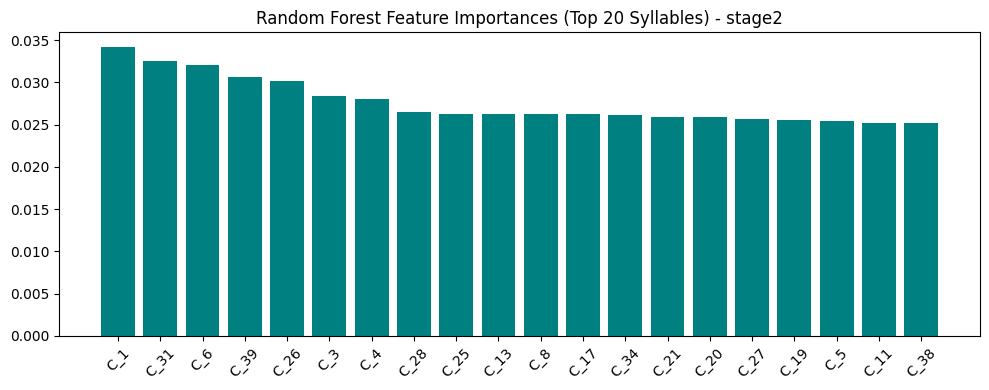

In [7]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Configuration ---
# Pointing to the newly generated file
GMM_H5_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5"
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

STAGE = "stage2"  
K_CLUSTERS = 40

print("1. Loading and cleaning metadata TSV...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

print(f"2. Extracting frequencies from {GMM_H5_PATH}...")
features_list = []

with h5py.File(GMM_H5_PATH, 'r') as f:
    video_names = list(f.keys())
    
    for vid in video_names:
        parts = vid.split('_')
        if len(parts) < 3:
            continue
            
        animal_id = parts[0]
        exp_stage = parts[1]
        age = parts[2]
        
        dataset_path = f"{vid}/{STAGE}/k_{K_CLUSTERS}"
        if dataset_path not in f:
            continue
            
        labels = f[dataset_path][:]
        
        # Calculate frequencies
        counts = np.bincount(labels, minlength=K_CLUSTERS)
        freqs = counts / len(labels) 
        
        row_data = {
            'video_name': vid,
            'animal_id': animal_id,
            'exp_stage': exp_stage,
            'age': age
        }
        
        for i in range(K_CLUSTERS):
            row_data[f'cluster_{i}'] = freqs[i]
            
        features_list.append(row_data)

freq_df = pd.DataFrame(features_list)

print("3. Merging with metadata...")
master_df = pd.merge(freq_df, meta_df, on='animal_id', how='inner')

# --- Classification Pipeline ---
print("\n" + "="*50)
print("4. Training Classifier")
print("="*50)

# We only want to predict strain, so we'll drop rows where strain is missing
master_df = master_df.dropna(subset=['strain'])

# Our features (X) are the 40 cluster frequency columns
feature_cols = [f'cluster_{i}' for i in range(K_CLUSTERS)]
X = master_df[feature_cols].values

# Our target (y) is the strain
y = master_df['strain'].values

print(f"Total valid samples: {len(X)}")
print(f"Number of unique strains: {len(np.unique(y))}")

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining Random Forest...")
# We use a Random Forest because it handles tabular frequency data beautifully
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n>>> Model: tailhip | Stage: {STAGE} <<<")
print(f">>> Accuracy on Test Set: {acc * 100:.2f}% <<<")
# print(f"(Baseline to beat: 35.00%)")

# Let's see the detailed breakdown for the top 5 most common strains in the test set
top_strains = pd.Series(y_test).value_counts().nlargest(5).index.tolist()
print("\nClassification Report (Top 5 Strains):")
print(classification_report(y_test, y_pred, labels=top_strains, zero_division=0))

# Feature Importance Plot
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
plt.title(f"Random Forest Feature Importances (Top 20 Syllables) - {STAGE}")
plt.bar(range(20), importances[indices][:20], align="center", color='teal')
plt.xticks(range(20), [f"C_{i}" for i in indices[:20]], rotation=45)
plt.tight_layout()
plt.show()

1. Loading and cleaning metadata TSV...
2. Extracting frequencies from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5...
3. Merging with metadata...

4. Training Classifier
Total valid samples: 3224
Number of unique strains: 83

Training Random Forest...

>>> Model: tailhip | Stage: stage1 <<<
>>> Accuracy on Test Set: 29.15% <<<

Classification Report (Top 5 Strains):
                   precision    recall  f1-score   support

B6CAST-129SPWK-F2       0.14      0.67      0.23        36
           FVB/NJ       0.41      0.79      0.54        14
           DBA/2J       0.14      0.23      0.18        13
            BXD34       0.27      0.60      0.38        10
        C57BL/6NJ       0.00      0.00      0.00         9

        micro avg       0.18      0.54      0.27        82
        macro avg       0.19      0.46      0.26        82
     weighted avg       0.19      0.54      0.27   

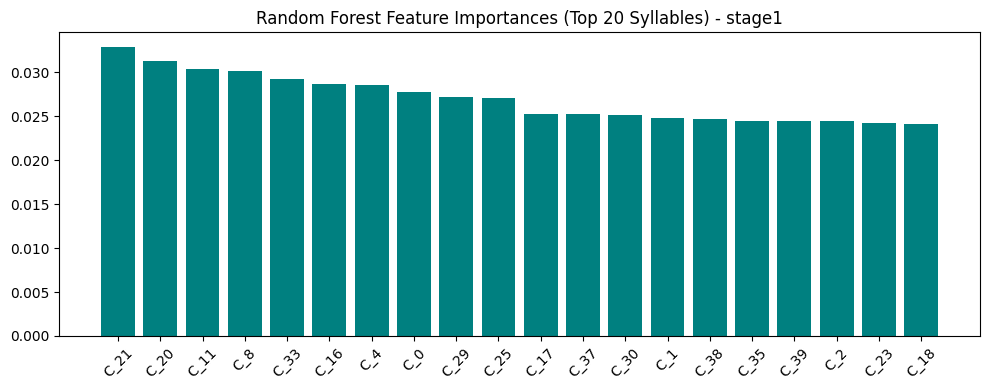

In [3]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Configuration ---
# Pointing to the newly generated file
GMM_H5_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/gmm_labels_tailhip_40.h5"
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

STAGE = "stage1"  
K_CLUSTERS = 40

print("1. Loading and cleaning metadata TSV...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

print(f"2. Extracting frequencies from {GMM_H5_PATH}...")
features_list = []

with h5py.File(GMM_H5_PATH, 'r') as f:
    video_names = list(f.keys())
    
    for vid in video_names:
        parts = vid.split('_')
        if len(parts) < 3:
            continue
            
        animal_id = parts[0]
        exp_stage = parts[1]
        age = parts[2]
        
        dataset_path = f"{vid}/{STAGE}/k_{K_CLUSTERS}"
        if dataset_path not in f:
            continue
            
        labels = f[dataset_path][:]
        
        # Calculate frequencies
        counts = np.bincount(labels, minlength=K_CLUSTERS)
        freqs = counts / len(labels) 
        
        row_data = {
            'video_name': vid,
            'animal_id': animal_id,
            'exp_stage': exp_stage,
            'age': age
        }
        
        for i in range(K_CLUSTERS):
            row_data[f'cluster_{i}'] = freqs[i]
            
        features_list.append(row_data)

freq_df = pd.DataFrame(features_list)

print("3. Merging with metadata...")
master_df = pd.merge(freq_df, meta_df, on='animal_id', how='inner')

# --- Classification Pipeline ---
print("\n" + "="*50)
print("4. Training Classifier")
print("="*50)

# We only want to predict strain, so we'll drop rows where strain is missing
master_df = master_df.dropna(subset=['strain'])

# Our features (X) are the 40 cluster frequency columns
feature_cols = [f'cluster_{i}' for i in range(K_CLUSTERS)]
X = master_df[feature_cols].values

# Our target (y) is the strain
y = master_df['strain'].values

print(f"Total valid samples: {len(X)}")
print(f"Number of unique strains: {len(np.unique(y))}")

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining Random Forest...")
# We use a Random Forest because it handles tabular frequency data beautifully
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n>>> Model: tailhip | Stage: {STAGE} <<<")
print(f">>> Accuracy on Test Set: {acc * 100:.2f}% <<<")
# print(f"(Baseline to beat: 35.00%)")

# Let's see the detailed breakdown for the top 5 most common strains in the test set
top_strains = pd.Series(y_test).value_counts().nlargest(5).index.tolist()
print("\nClassification Report (Top 5 Strains):")
print(classification_report(y_test, y_pred, labels=top_strains, zero_division=0))

# Feature Importance Plot
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
plt.title(f"Random Forest Feature Importances (Top 20 Syllables) - {STAGE}")
plt.bar(range(20), importances[indices][:20], align="center", color='teal')
plt.xticks(range(20), [f"C_{i}" for i in indices[:20]], rotation=45)
plt.tight_layout()
plt.show()


4. Filtering Data & Setup
Removed 'B6CAST-129SPWK-F2' and strains with < 20 recordings.
Remaining valid samples: 2970
Remaining unique strains: 77

5. 5-Fold Cross-Validation Leaderboard
Evaluating Random Forest...
  -> Mean Accuracy: 34.75% (± 0.59%)
Evaluating Extra Trees...
  -> Mean Accuracy: 34.92% (± 1.33%)
Evaluating Logistic Regression...
  -> Mean Accuracy: 45.25% (± 0.44%)
Evaluating SVM (RBF)...
  -> Mean Accuracy: 30.54% (± 0.42%)
Evaluating K-Nearest Neighbors...
  -> Mean Accuracy: 19.70% (± 0.69%)


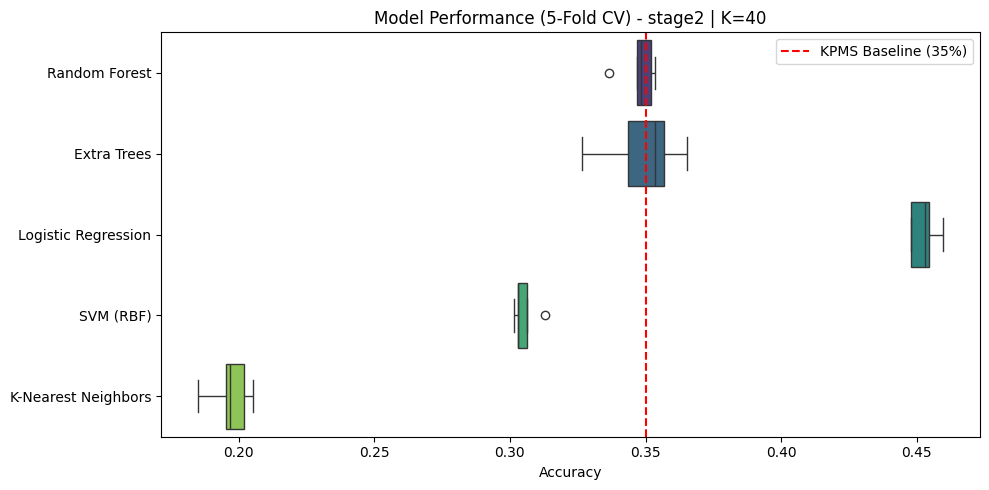

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*50)
print("4. Filtering Data & Setup")
print("="*50)

# 1. Drop rows with missing strain info
df_filtered = master_df.dropna(subset=['strain']).copy()

# 2. Remove the "fake" over-represented strain
fake_strain = 'B6CAST-129SPWK-F2'
df_filtered = df_filtered[df_filtered['strain'] != fake_strain]

# 3. Remove strains with fewer than 20 recordings
strain_counts = df_filtered['strain'].value_counts()
valid_strains = strain_counts[strain_counts >= 20].index
df_filtered = df_filtered[df_filtered['strain'].isin(valid_strains)]

print(f"Removed '{fake_strain}' and strains with < 20 recordings.")
print(f"Remaining valid samples: {len(df_filtered)}")
print(f"Remaining unique strains: {len(valid_strains)}")

# Extract Features (X) and Target (y)
feature_cols = [f'cluster_{i}' for i in range(K_CLUSTERS)]
X = df_filtered[feature_cols].values
y = df_filtered['strain'].values

print("\n" + "="*50)
print("5. 5-Fold Cross-Validation Leaderboard")
print("="*50)

# Setup models. We use make_pipeline with StandardScaler because 
# Logistic Regression and SVMs are highly sensitive to unscaled data.
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
}

# 5-Fold Stratified CV ensures each fold has the same ratio of strains
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    # cv uses 5 folds, scoring uses accuracy
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=1) 
    results[name] = scores
    print(f"  -> Mean Accuracy: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# --- Plot the Leaderboard ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(results), orient="h", palette="viridis")
plt.title(f"Model Performance (5-Fold CV) - {STAGE} | K={K_CLUSTERS}")
plt.xlabel("Accuracy")
plt.axvline(x=0.35, color='red', linestyle='--', label='KPMS Baseline (35%)')
plt.legend()
plt.tight_layout()
plt.show()

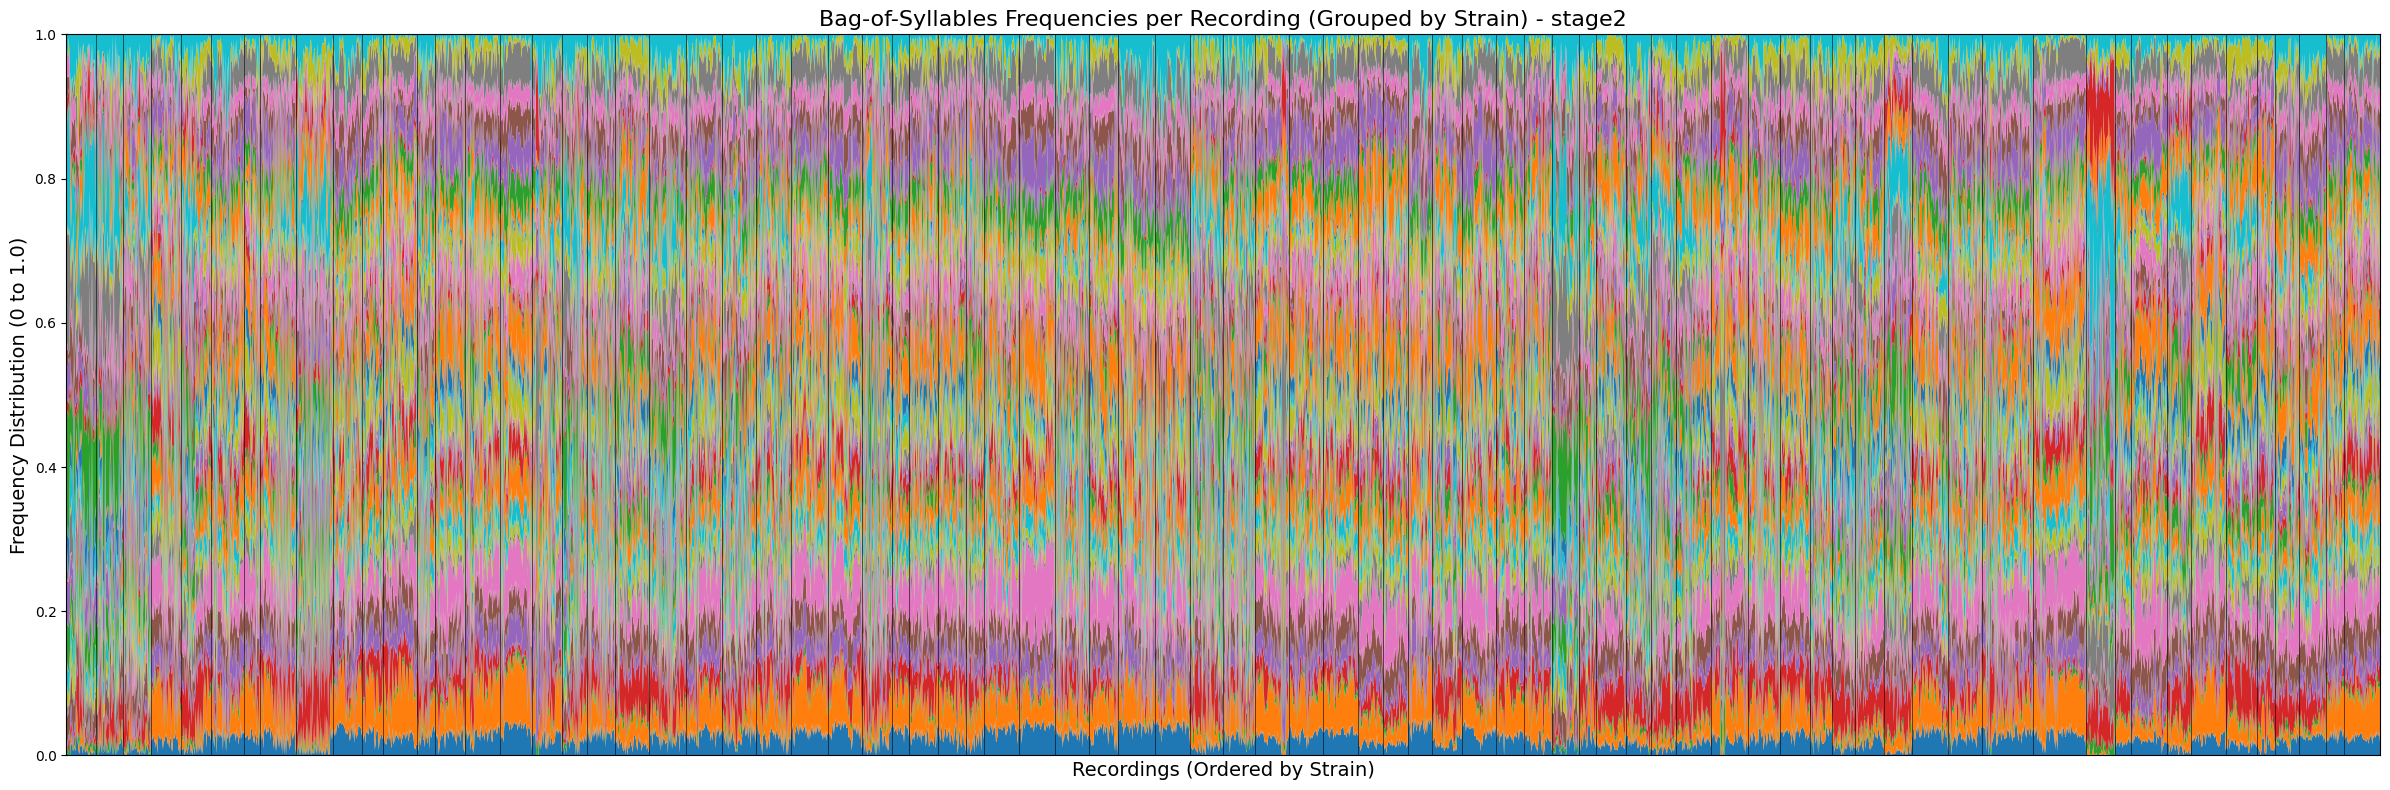

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Sort the dataframe so recordings of the same strain are grouped together
df_sorted = df_filtered.sort_values(by=['strain', 'video_name']).reset_index(drop=True)

# Extract the frequency data and transpose it for stackplot (shape: 40 clusters x N recordings)
features_viz = df_sorted[feature_cols].values.T

# Find the exact indices where the strain changes so we can draw boundary lines
strain_boundaries = np.where(df_sorted['strain'].ne(df_sorted['strain'].shift()))[0]

# 2. Plot the Stacked Area (looks like a dense stacked bar chart)
plt.figure(figsize=(24, 8))
plt.stackplot(range(len(df_sorted)), features_viz, labels=feature_cols, cmap='tab20')

# 3. Draw thin vertical lines to separate the strains
for idx in strain_boundaries:
    plt.axvline(x=idx, color='black', linewidth=0.5, alpha=0.8)

plt.margins(0, 0)
plt.title(f"Bag-of-Syllables Frequencies per Recording (Grouped by Strain) - {STAGE}", fontsize=16)
plt.xlabel("Recordings (Ordered by Strain)", fontsize=14)
plt.ylabel("Frequency Distribution (0 to 1.0)", fontsize=14)

# We hide the x-ticks because 3,000 video names would be a black smear
plt.xticks([]) 

plt.tight_layout()
plt.show()

Training Logistic Regression for Confusion Matrix...


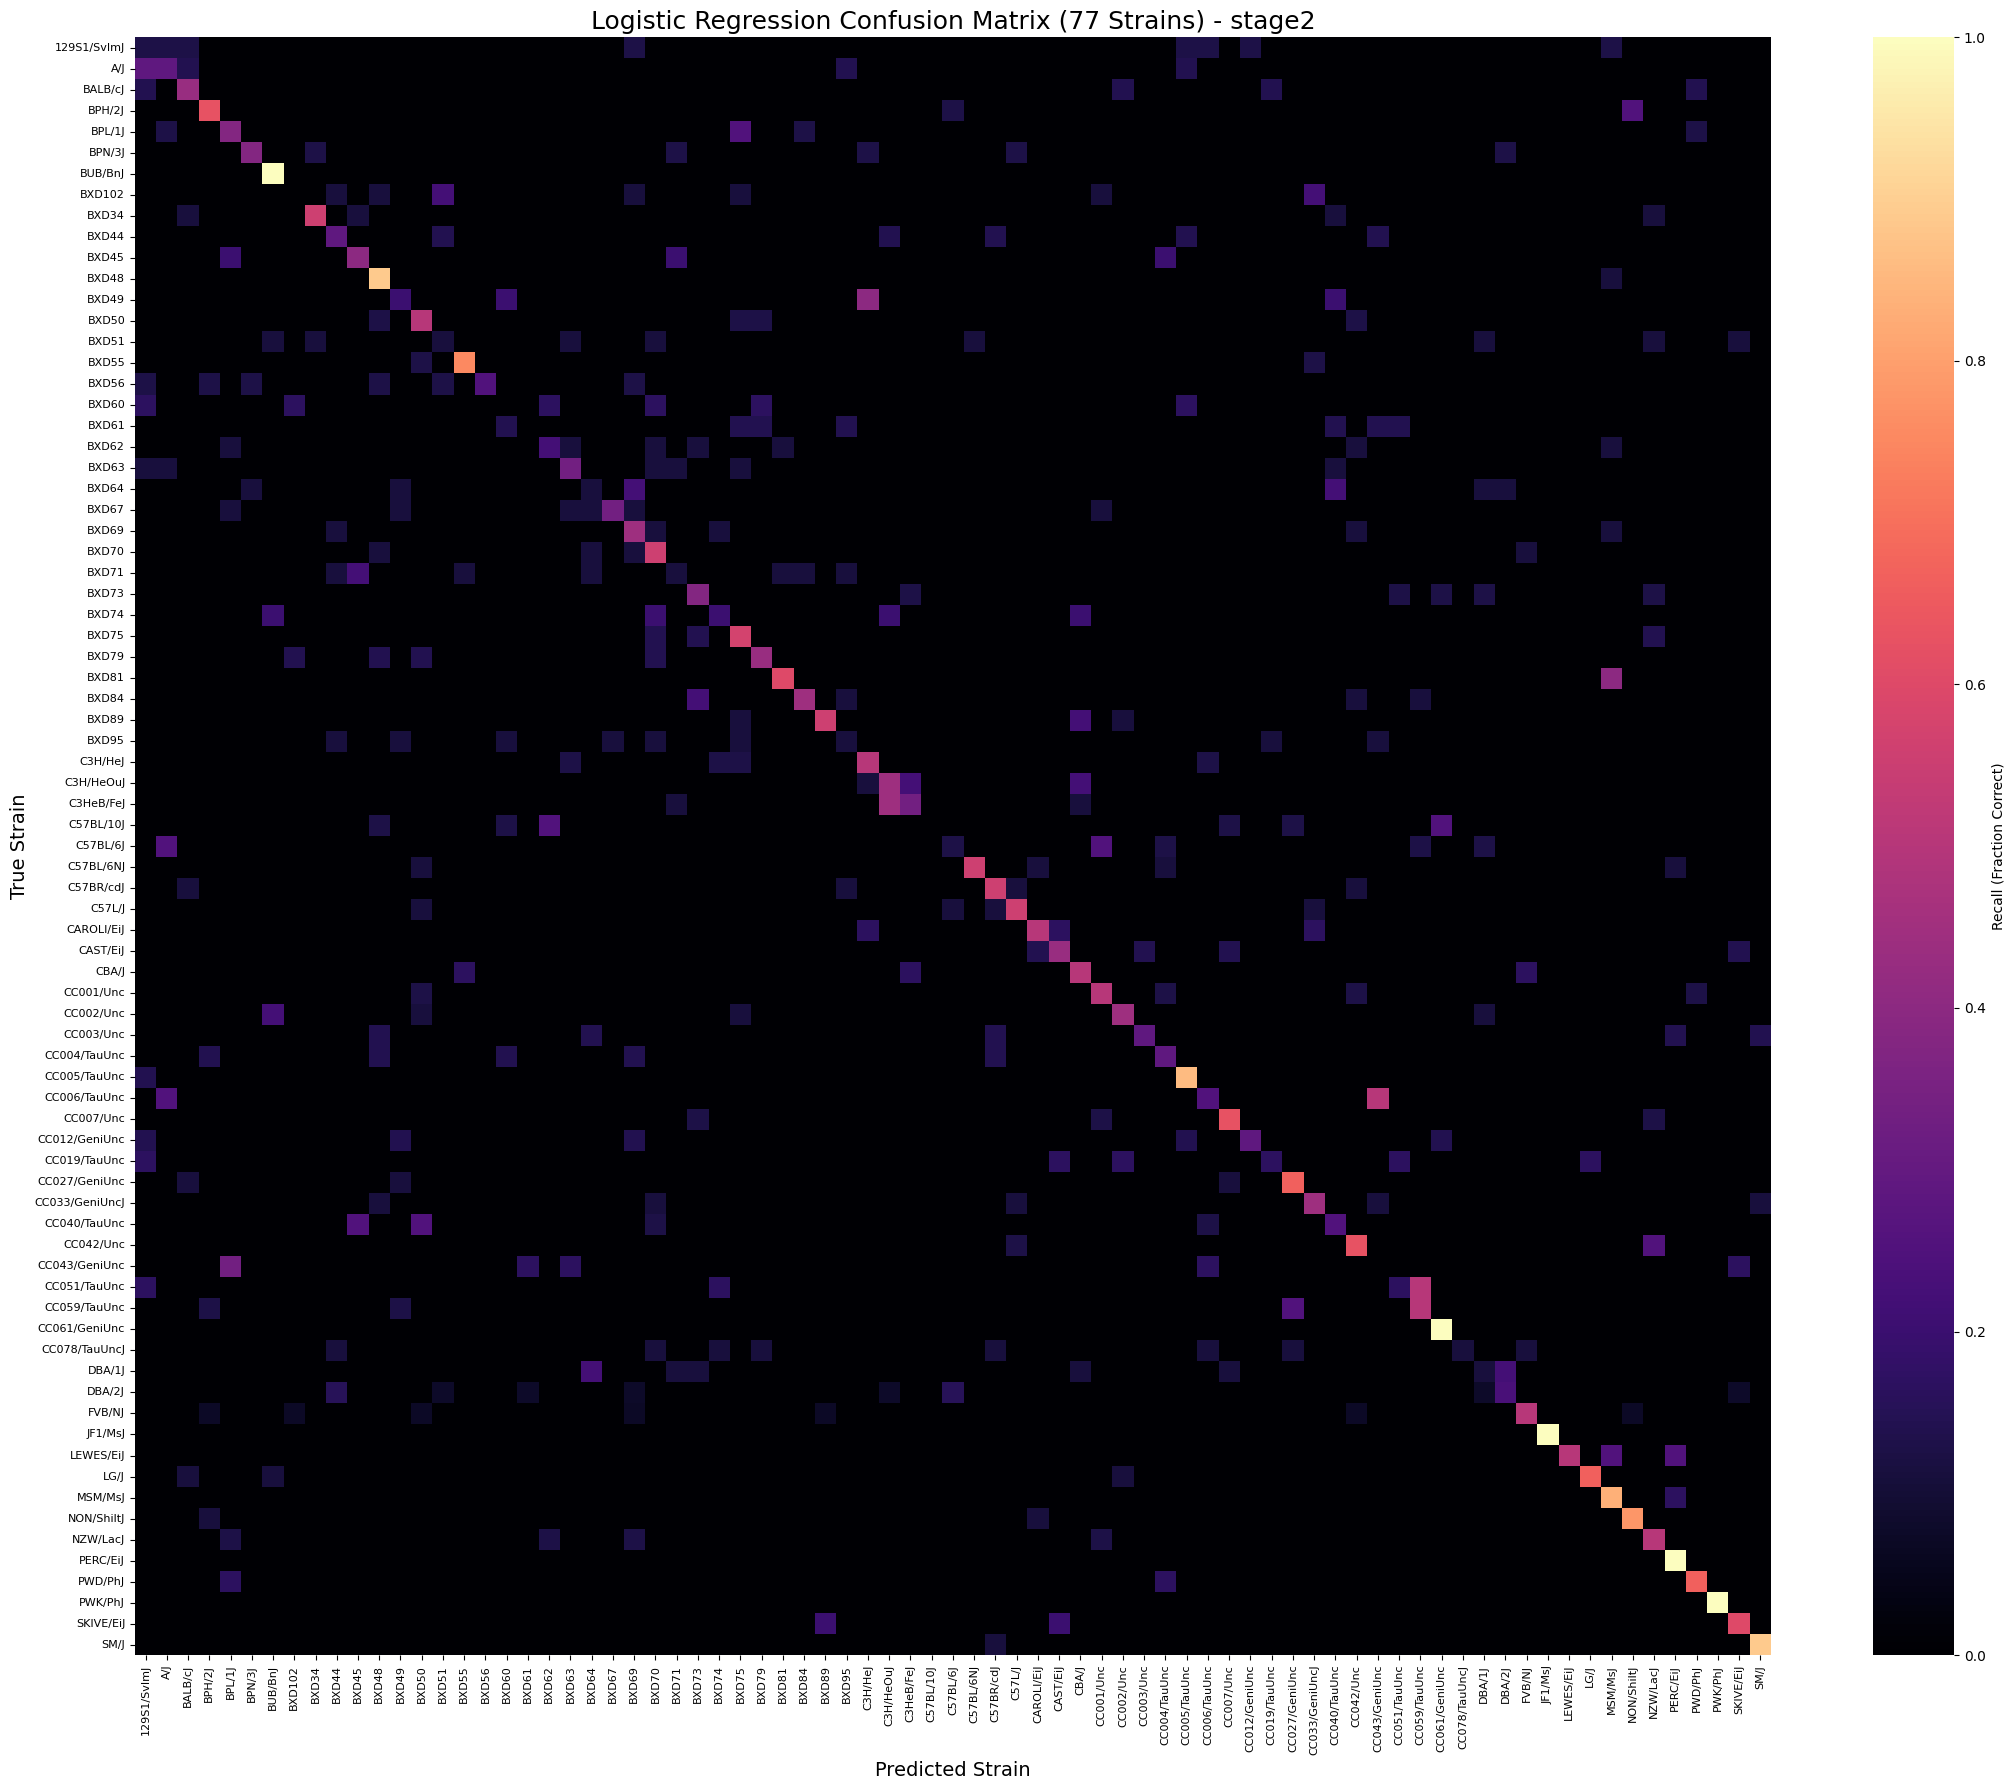

In [10]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# 1. Create a single Train/Test split to evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train the winning Logistic Regression model
print("Training Logistic Regression for Confusion Matrix...")
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 3. Compute the Confusion Matrix
# normalize='true' ensures rows sum to 1.0 (showing percentage of correct predictions per strain)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_, normalize='true')

# 4. Plot the Matrix
plt.figure(figsize=(22, 18))
sns.heatmap(
    cm, 
    cmap='magma',     # 'magma' or 'viridis' is great for spotting bright spots on the diagonal
    xticklabels=clf.classes_, 
    yticklabels=clf.classes_,
    cbar_kws={'label': 'Recall (Fraction Correct)'}
)

plt.title(f"Logistic Regression Confusion Matrix ({len(clf.classes_)} Strains) - {STAGE}", fontsize=18)
plt.xlabel("Predicted Strain", fontsize=14)
plt.ylabel("True Strain", fontsize=14)

# Rotate labels so they are readable
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
import h5py
from pathlib import Path

# --- Paths to compare ---
KPMS_RESULTS_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/interim/keypoint_moseq_project/shuffle-3_projset-0/shuffle-3_projset-0_modset-0/results.h5"

# Assuming you named the output from the conversion script this:
GMM_RESULTS_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5"


def inspect_h5_structure(filepath, max_videos_to_show=2):
    path = Path(filepath)
    print(f"{'='*60}")
    print(f"FILE: {path.name}")
    print(f"{'='*60}")
    
    if not path.exists():
        print(f"File not found at: {path}")
        return

    with h5py.File(path, 'r') as f:
        root_keys = list(f.keys())
        
        # Check for root-level datasets/attributes (KPMS often stores global model parameters here)
        root_datasets = [k for k in root_keys if isinstance(f[k], h5py.Dataset)]
        video_groups = [k for k in root_keys if isinstance(f[k], h5py.Group)]
        
        print(f"Total Root-Level Datasets: {len(root_datasets)}")
        if root_datasets:
            for k in root_datasets[:5]:
                print(f"  ├── [Root Dataset] {k}: shape {f[k].shape}, dtype {f[k].dtype}")
            if len(root_datasets) > 5:
                print(f"  └── ...and {len(root_datasets)-5} more.")
                
        print(f"\nTotal Video Groups: {len(video_groups)}")
        
        # Print the internal structure of the first few videos
        for vid in video_groups[:max_videos_to_show]:
            print(f"\n└── [Group] {vid}")
            grp = f[vid]
            for subkey in grp.keys():
                item = grp[subkey]
                if isinstance(item, h5py.Dataset):
                    print(f"    ├── [Dataset] {subkey}: shape {item.shape}, dtype {item.dtype}")
                elif isinstance(item, h5py.Group):
                    print(f"    ├── [Group] {subkey}")
                    # Look one layer deeper just in case
                    for subsubkey in item.keys():
                        subitem = item[subsubkey]
                        if isinstance(subitem, h5py.Dataset):
                            print(f"    │   ├── [Dataset] {subsubkey}: shape {subitem.shape}, dtype {subitem.dtype}")
                            
        if len(video_groups) > max_videos_to_show:
            print(f"\n└── ... plus {len(video_groups) - max_videos_to_show} more video groups.")
    print("\n")

# Run the comparison
inspect_h5_structure(KPMS_RESULTS_PATH)
inspect_h5_structure(GMM_RESULTS_PATH)

FILE: results.h5
Total Root-Level Datasets: 0

Total Video Groups: 3224

└── [Group] HDP-002539_HAB_Adult_371
    ├── [Dataset] centroid: shape (34003, 2), dtype float64
    ├── [Dataset] heading: shape (34003,), dtype float64
    ├── [Dataset] latent_state: shape (34003, 2), dtype float64
    ├── [Dataset] syllable: shape (34003,), dtype int64

└── [Group] HDP-002539_RET_Adult_419
    ├── [Dataset] centroid: shape (8630, 2), dtype float64
    ├── [Dataset] heading: shape (8630,), dtype float64
    ├── [Dataset] latent_state: shape (8630, 2), dtype float64
    ├── [Dataset] syllable: shape (8630,), dtype int64

└── ... plus 3222 more video groups.


FILE: results_40_clusters.h5
Total Root-Level Datasets: 0

Total Video Groups: 3224

└── [Group] HDP-002539_HAB_Adult_371
    ├── [Dataset] centroid: shape (34003, 2), dtype float64
    ├── [Dataset] heading: shape (34003,), dtype float64
    ├── [Dataset] latent_state: shape (34003, 192), dtype float64
    ├── [Dataset] syllable: shape (34

In [12]:
import h5py
import pickle
import numpy as np

# --- Paths ---
KPMS_RESULTS_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/interim/keypoint_moseq_project/shuffle-3_projset-0/shuffle-3_projset-0_modset-0/results.h5"
PKL_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/ofdpipe/tmp/data/interim/keypoint_moseq_data/shuffle-3/shuffle-3_split-train.pkl"

print("Loading raw coordinates...")
with open(PKL_PATH, "rb") as f:
    raw_data = pickle.load(f)
keypoints_dict = raw_data[0]
keypoint_names = list(raw_data[2])

# Indices for our guesses
c_idx = keypoint_names.index("mouse_center")
n_idx = keypoint_names.index("neck")
t_idx = keypoint_names.index("tail_base")
nose_idx = keypoint_names.index("nose")

print("Loading KPMS ground truth...\n")
with h5py.File(KPMS_RESULTS_PATH, 'r') as f:
    # Get the first video in the file
    vid = list(f.keys())[0]
    print(f"Testing on video: {vid}")
    
    # Grab first 5 frames from KPMS results
    kpms_centroid = f[vid]['centroid'][:5]
    kpms_heading = f[vid]['heading'][:5]
    
    # Grab first 5 frames of raw coordinates
    raw_kpts = keypoints_dict[vid][:5]
    
    # --- Our Calculations ---
    # Guess 1: Centroid is just mouse_center
    my_centroid = raw_kpts[:, c_idx, :]
    
    # Guess 2: Heading is Neck minus Tail Base
    vec_neck_tail = raw_kpts[:, n_idx, :] - raw_kpts[:, t_idx, :]
    angle_neck_tail = np.arctan2(vec_neck_tail[:, 1], vec_neck_tail[:, 0])
    
    # Guess 3: Heading is Nose minus Tail Base
    vec_nose_tail = raw_kpts[:, nose_idx, :] - raw_kpts[:, t_idx, :]
    angle_nose_tail = np.arctan2(vec_nose_tail[:, 1], vec_nose_tail[:, 0])
    
    # --- Print Comparisons ---
    print("\n--- CENTROID COMPARISON ---")
    for i in range(5):
        print(f"Frame {i}:")
        print(f"  KPMS Centroid:      {kpms_centroid[i]}")
        print(f"  My 'mouse_center':  {my_centroid[i]}")

    print("\n--- HEADING COMPARISON (Radians) ---")
    for i in range(5):
        print(f"Frame {i}:")
        print(f"  KPMS Heading:       {kpms_heading[i]:.4f}")
        print(f"  My (Neck - Tail):   {angle_neck_tail[i]:.4f}")
        print(f"  My (Nose - Tail):   {angle_nose_tail[i]:.4f}")

Loading raw coordinates...
Loading KPMS ground truth...

Testing on video: HDP-002539_HAB_Adult_371

--- CENTROID COMPARISON ---
Frame 0:
  KPMS Centroid:      [130.85815808 127.29858639]
  My 'mouse_center':  [140.26539612 121.5185318 ]
Frame 1:
  KPMS Centroid:      [130.27839143 127.93571538]
  My 'mouse_center':  [140.06213379 121.72812653]
Frame 2:
  KPMS Centroid:      [130.41412795 126.67438032]
  My 'mouse_center':  [140.57037354 121.76651001]
Frame 3:
  KPMS Centroid:      [130.76564749 125.76009954]
  My 'mouse_center':  [141.22180176 121.0072403 ]
Frame 4:
  KPMS Centroid:      [130.80690147 125.555086  ]
  My 'mouse_center':  [141.51235962 121.14924622]

--- HEADING COMPARISON (Radians) ---
Frame 0:
  KPMS Heading:       2.2041
  My (Neck - Tail):   1.8530
  My (Nose - Tail):   2.1701
Frame 1:
  KPMS Heading:       2.0036
  My (Neck - Tail):   1.8434
  My (Nose - Tail):   2.1732
Frame 2:
  KPMS Heading:       2.1813
  My (Neck - Tail):   1.8352
  My (Nose - Tail):   2.1693


Loading custom GMM results from:
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5
Loading custom GMM results from:
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5
Loaded 3224 recordings

Loading keypoints...
Loaded 3224 recordings

Loading video frame indexes...
Loaded video frame indexes for 3689 videos
Filtered frame indexes to match 3224 valid result videos.

Generating Trajectory Plots...
Saving trajectory plots to /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/dummy_kptmq/gmm_40_clusters_output/trajectory_plots


Generating trajectory plots: 100%|██████| 40/40 [00:14<00:00,  2.67it/s]


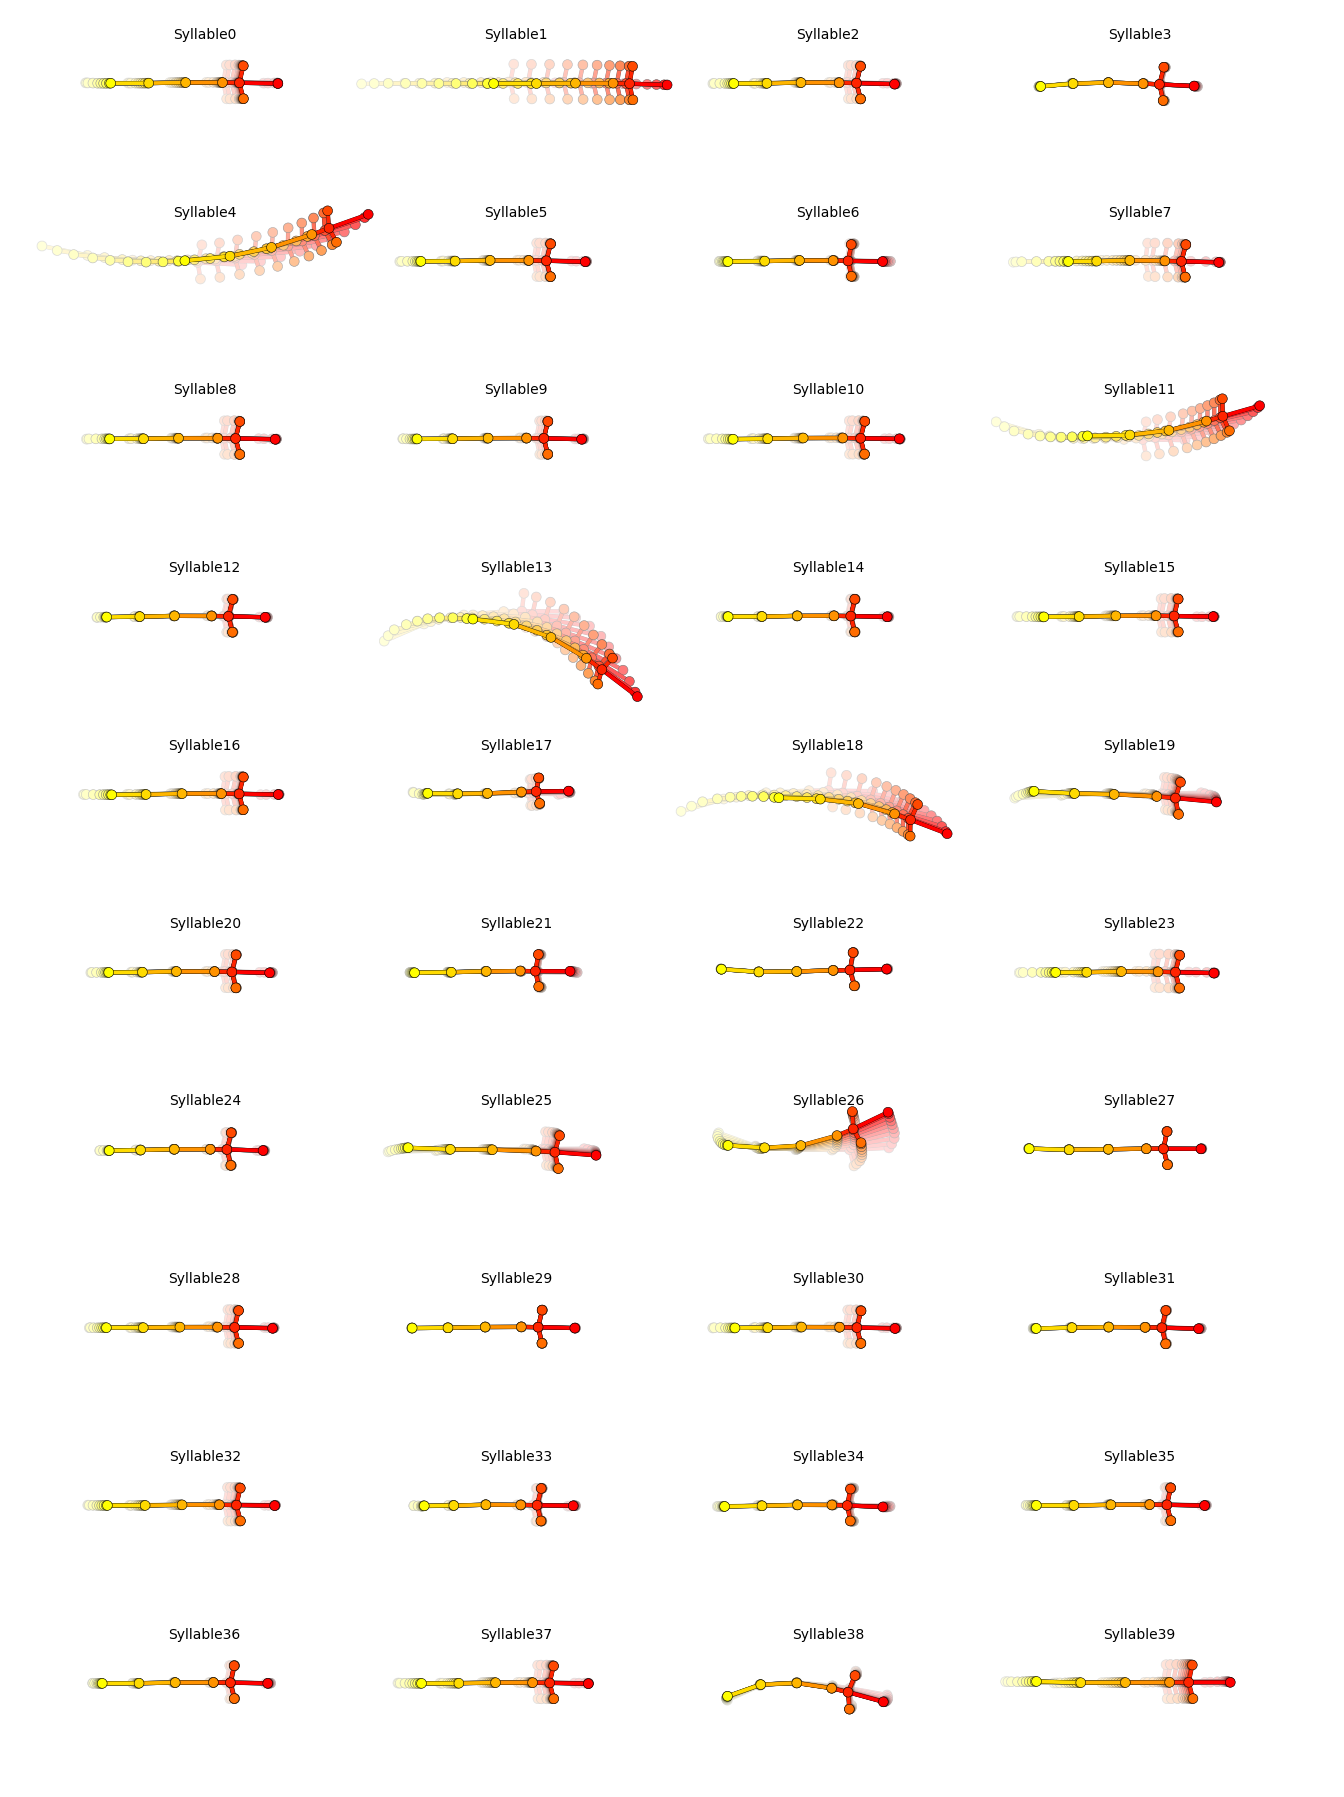


Generating Grid Movies (this will take some time)...


TypeError: keypoint_moseq.viz.generate_grid_movies() got multiple values for keyword argument 'video_dir'

In [ ]:
import os
import pickle
import keypoint_moseq as kpms
from pathlib import Path

# ==============================================================================
# 1. Setup & Paths
# ==============================================================================
shuffle = 3
projset = 0
modset = 0

global_project_path = "/scratch/michal/projects/dvc_ofd_2025/data/interim"

# Your custom hBehaveMAE GMM results file
results_path = Path("/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5")

# Standard KPMS Data Paths
recording_path = os.path.join(global_project_path, f"keypoint_moseq_data/shuffle-{shuffle}/shuffle-{shuffle}_split-train.pkl")
video_dir_path = os.path.join(global_project_path, "video")
frame_indexes_path = os.path.join(global_project_path, "video_trim_export/openfield_ORT_video_frame_indexes.pkl")

# KPMS Project Environment
# kpms_project_path = os.path.join(global_project_path, f"keypoint_moseq_project/shuffle-{shuffle}_projset-{projset}")
kpms_project_path = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/dummy_kptmq/"
original_model_name = f"shuffle-{shuffle}_projset-{projset}_modset-{modset}"

# This is where your new plots and videos will be saved!
output_model_name = "gmm_40_clusters_output" 

# ==============================================================================
# 2. Load Data
# ==============================================================================
print(f"Loading custom GMM results from:\n{results_path}")
# results = kpms.load_results(path = results_path)


import h5py

print(f"Loading custom GMM results from:\n{results_path}")

# Load manually instead of using kpms.load_results()
results = {}
with h5py.File(results_path, 'r') as f:
    for vid_name in f.keys():
        results[vid_name] = {
            'syllable': f[vid_name]['syllable'][:],
            'centroid': f[vid_name]['centroid'][:],
            'heading': f[vid_name]['heading'][:]
        }

print(f"Loaded {len(results)} recordings")

print("\nLoading keypoints...")
with open(recording_path, 'rb') as f:
    coordinates, confidences, bodyparts = pickle.load(f)
print(f"Loaded {len(coordinates)} recordings")

print("\nLoading video frame indexes...")
with open(frame_indexes_path, 'rb') as f:
    video_frame_indexes = pickle.load(f)
print(f"Loaded video frame indexes for {len(video_frame_indexes)} videos")

# Clean up frame indexes (remove videos that aren't in your results)
video_frame_key_diff = set(video_frame_indexes.keys()) - set(results.keys())
for key in video_frame_key_diff:
    video_frame_indexes.pop(key, None)
print(f"Filtered frame indexes to match {len(video_frame_indexes)} valid result videos.")

# ==============================================================================
# 3. Load Config & Create Output Directory
# ==============================================================================
# Load config from the original model to inherit the skeleton and bodypart settings
cfg = kpms.load_config(kpms_project_path, original_model_name)

# Ensure the new output folder exists inside the KPMS project directory
os.makedirs(os.path.join(kpms_project_path, output_model_name), exist_ok=True)

# ==============================================================================
# 4. Generate Visualizations!
# ==============================================================================

print("\nGenerating Trajectory Plots...")
# This will output to: kpms_project_path/gmm_40_clusters_output/trajectory_plots
kpms.generate_trajectory_plots(
    coordinates=coordinates,
    results=results,
    project_dir=kpms_project_path,
    model_name=output_model_name,
    min_frequency=0,
    density_sample=False,
    **cfg
)


In [6]:
import os
import pickle
import keypoint_moseq as kpms
from pathlib import Path

# ==============================================================================
# 1. Setup & Paths
# ==============================================================================
shuffle = 3
projset = 0
modset = 0

global_project_path = "/scratch/michal/projects/dvc_ofd_2025/data/interim"

# Your custom hBehaveMAE GMM results file
results_path = Path("/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5")

# Standard KPMS Data Paths
recording_path = os.path.join(global_project_path, f"keypoint_moseq_data/shuffle-{shuffle}/shuffle-{shuffle}_split-train.pkl")
video_dir_path = os.path.join(global_project_path, "video")
frame_indexes_path = os.path.join(global_project_path, "video_trim_export/openfield_ORT_video_frame_indexes.pkl")

# KPMS Project Environment
# kpms_project_path = os.path.join(global_project_path, f"keypoint_moseq_project/shuffle-{shuffle}_projset-{projset}")
kpms_project_path = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/dummy_kptmq/"
original_model_name = f"shuffle-{shuffle}_projset-{projset}_modset-{modset}"

# This is where your new plots and videos will be saved!
output_model_name = "gmm_40_clusters_output" 

# ==============================================================================
# 2. Load Data
# ==============================================================================
print(f"Loading custom GMM results from:\n{results_path}")
# results = kpms.load_results(path = results_path)


import h5py

print(f"Loading custom GMM results from:\n{results_path}")

# Load manually instead of using kpms.load_results()
results = {}
with h5py.File(results_path, 'r') as f:
    for vid_name in f.keys():
        results[vid_name] = {
            'syllable': f[vid_name]['syllable'][:],
            'centroid': f[vid_name]['centroid'][:],
            'heading': f[vid_name]['heading'][:]
        }

print(f"Loaded {len(results)} recordings")

print("\nLoading keypoints...")
with open(recording_path, 'rb') as f:
    coordinates, confidences, bodyparts = pickle.load(f)
print(f"Loaded {len(coordinates)} recordings")

print("\nLoading video frame indexes...")
with open(frame_indexes_path, 'rb') as f:
    video_frame_indexes = pickle.load(f)
print(f"Loaded video frame indexes for {len(video_frame_indexes)} videos")

# Clean up frame indexes (remove videos that aren't in your results)
video_frame_key_diff = set(video_frame_indexes.keys()) - set(results.keys())
for key in video_frame_key_diff:
    video_frame_indexes.pop(key, None)
print(f"Filtered frame indexes to match {len(video_frame_indexes)} valid result videos.")

# ==============================================================================
# 3. Load Config & Create Output Directory
# ==============================================================================
# Load config from the original model to inherit the skeleton and bodypart settings
cfg = kpms.load_config(kpms_project_path, original_model_name)

# Ensure the new output folder exists inside the KPMS project directory
os.makedirs(os.path.join(kpms_project_path, output_model_name), exist_ok=True)

# ==============================================================================
# 4. Generate Visualizations!
# ==============================================================================

print("\nGenerating Grid Movies (this will take some time)...")
# This will output to: kpms_project_path/gmm_40_clusters_output/grid_movies
kpms.generate_grid_movies(
    results=results,
    project_dir=kpms_project_path,
    model_name=output_model_name,
    video_dir=video_dir_path,
    video_frame_indexes=video_frame_indexes,
    coordinates=coordinates,
    video_extension='mpg',  # Adjust this to 'mp4' if your raw videos are mp4s
    overlay_keypoints=True,
    **cfg
)

print("\nSuccess! All visualizations are rendering to your project directory.")

Loading custom GMM results from:
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5
Loading custom GMM results from:
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/results_40_clusters.h5
Loaded 3224 recordings

Loading keypoints...
Loaded 3224 recordings

Loading video frame indexes...
Loaded video frame indexes for 3689 videos
Filtered frame indexes to match 3224 valid result videos.

Generating Grid Movies (this will take some time)...


TypeError: keypoint_moseq.viz.generate_grid_movies() got multiple values for keyword argument 'video_dir'

In [7]:
# ==============================================================================
# 4. Generate Visualizations!
# ==============================================================================

print("\nGenerating Grid Movies (this will take some time)...")

# 1. Inject your explicit overrides directly into the config dictionary
cfg['video_dir'] = video_dir_path
cfg['video_extension'] = 'mpg'  # Adjust to 'mp4' if needed
cfg['overlay_keypoints'] = True

# 2. Call the function by unpacking ONLY the safely updated dictionary
kpms.generate_grid_movies(
    results=results,
    project_dir=kpms_project_path,
    model_name=output_model_name,
    video_frame_indexes=video_frame_indexes,
    coordinates=coordinates,
    **cfg
)

print("\nSuccess! All visualizations are rendering to your project directory.")


Generating Grid Movies (this will take some time)...
Writing grid movies to /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/gmm_40_clustering_outputs/dummy_kptmq/gmm_40_clusters_output/grid_movies


[mpeg4 @ 0x64f86146ab00] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64fcd4746dc0] warning: first frame is no keyframe
[mpeg4 @ 0x64fcd4746dc0] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64f89b6f1c80] warning: first frame is no keyframe
[mpeg4 @ 0x64facee70880] warning: first frame is no keyframe
[mpeg4 @ 0x64fcd4746dc0] warning: first frame is no keyframe
[mpeg4 @ 0x64f8533fde00] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300]

Using window size of 192 pixels


Generating grid movies:   0%|                    | 0/37 [00:00<?, ?it/s][mpeg4 @ 0x64fa3fb5f100] warning: first frame is no keyframe
[mpeg4 @ 0x64f88e4bb540] warning: first frame is no keyframe
[mpeg4 @ 0x64fab8cf3340] warning: first frame is no keyframe
[mpeg4 @ 0x64f85fbfbb00] warning: first frame is no keyframe
[mpeg4 @ 0x64fa3fb5f100] warning: first frame is no keyframe
[mpeg4 @ 0x64f8655df780] warning: first frame is no keyframe
[mpeg4 @ 0x64f899271d40] warning: first frame is no keyframe
[mpeg4 @ 0x64f89844e9c0] warning: first frame is no keyframe
[mpeg4 @ 0x64f85a91ab00] warning: first frame is no keyframe
[mpeg4 @ 0x64f8597abf40] warning: first frame is no keyframe
[mpeg4 @ 0x64f891589b80] warning: first frame is no keyframe
[mpeg4 @ 0x64fa11257d40] warning: first frame is no keyframe
[mpeg4 @ 0x64f884980f00] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300] warning: first frame is no keyframe
[mpeg4 @ 0x64fbd1c47300] warning: first frame is no keyframe
[mpeg4 @ 0x64


Success! All visualizations are rendering to your project directory.
